<a href="https://colab.research.google.com/github/rajiv-ranjan/cds-mini-projects/blob/saif/m5/mini-project-2/M5_NB_MiniProject_02_Fare_Amount_Prediction_Using_Dask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini Project: Implementation of Linear Regression on a Large Dataset Using Dask Library

## Learning Objectives

At the end of the mini-project, you will be able to :

- understand how dask handles large dataset over pandas dataframe
- perform exploratory data analysis on a large dataset (2 Million rows) using dask
- implement linear regression model using dask library and make predictions


## Problem Statement

 Predict the taxi fare amount in New York city using Dask-ML.

## Information

### Dask
[Dask](https://dask.pydata.org/en/latest/) is an open source project that gives abstractions over NumPy Arrays, Pandas Dataframes and regular lists, allowing you to run operations on them in parallel, using multicore processing.

We can summarize the basics of Dask as follows:

* processes data that doesn’t fit into memory by breaking it into blocks and specifying task chains

* parallelizes execution of tasks across cores and even nodes of a cluster

* moves computation to the data rather than the other way around, to minimize communication overhead

### Dataset

The dataset is based on the 2016 NYC Yellow Cab trip record data made available in Big Query on Google Cloud Platform. Its variables are as follows:
![Dataset](https://cdn.exec.talentsprint.com/static/cds/NYC_Taxi_data_description_image.png)




Note that the features the ' Dask_MP_dataset.csv' file that is provided for this miniproject varies slightly in terms of included features, as compared to the original dataset described above. Please proceed with the provided csv file.

## Grading = 10 Points

In [87]:
#@title Install Dask dependencies and restart runtime
!pip -qq install dask-ml
!pip -qq install dask
!pip -qq install dask[complete]
!pip install --upgrade --force-reinstall dask distributed
!pip -qq install mimesis

  Using cached dask-2025.5.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached distributed-2025.5.1-py3-none-any.whl.metadata (3.4 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached partd-1.4.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached PyYAML-6.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached toolz-1.0.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached importlib_metadata-8.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached locket-1.0.0-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached msgpack-1.1.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.4 kB)
  Using cached psutil-7.0.0-cp36-abi3-manylinux_2_12_x86_64.manyl

#### Importing Necessary Packages

In [1]:
import warnings
warnings.filterwarnings('ignore')
import dask
import dask.dataframe as dd
import dask.array as da
from dask_ml.linear_model import LinearRegression
from dask_ml.model_selection import train_test_split
from dask_ml.metrics import mean_squared_error, r2_score
from dask.distributed import Client
import time as time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from dask.distributed import Client, progress
client = Client()

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-wd2nxrmj', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-cm5r_ywo', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-d8rca9sk', purging
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40051
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42413'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40401'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40867'
INFO:distributed.nanny:        Start Nanny 

In [2]:
#@title Download the data
!wget https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Dask_MP_dataset.csv

--2025-05-25 05:16:28--  https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Dask_MP_dataset.csv
Resolving cdn.iisc.talentsprint.com (cdn.iisc.talentsprint.com)... 172.105.52.210
Connecting to cdn.iisc.talentsprint.com (cdn.iisc.talentsprint.com)|172.105.52.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231900522 (221M) [application/octet-stream]
Saving to: ‘Dask_MP_dataset.csv.2’

Dask_MP_dataset.csv 100%[===================>] 221.16M  11.8MB/s    in 21s     

2025-05-25 05:16:51 (10.4 MB/s) - ‘Dask_MP_dataset.csv.2’ saved [231900522/231900522]



#### Exercise 1: Read the dataset using dask library and compare the time of execution with pandas library. (1 Point)

**Hint:** pass `dtype` for passenger_count as `int64`

In [3]:
%%time
# YOUR CODE HERE
file_path = 'Dask_MP_dataset.csv'
dtypes = {'passenger_count': 'int64'}

#time for Dask
start_time1 = time.time()
df_dask = dd.read_csv(file_path, dtype=dtypes)
end_time1 = time.time()
dask_time = end_time1 - start_time1

print(f"Dask read time: {dask_time:.4f} seconds")

start_compute_time = time.time()
df_dask.compute()
end_compute_time = time.time()
compute_time = end_compute_time - start_compute_time

print(f"Dask compute time: {compute_time:.4f} seconds")

Dask read time: 0.0179 seconds
Dask compute time: 4.4433 seconds
CPU times: user 419 ms, sys: 466 ms, total: 884 ms
Wall time: 4.46 s


In [4]:
print(df_dask.head())
print("\n No of Rows:", len(df_dask))

   Unnamed: 0                            key  fare_amount  \
0           0    2009-06-15 17:26:21.0000001          4.5   
1           1    2010-01-05 16:52:16.0000002         16.9   
2           2   2011-08-18 00:35:00.00000049          5.7   
3           3    2012-04-21 04:30:42.0000001          7.7   
4           4  2010-03-09 07:51:00.000000135          5.3   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2009-06-15 17:26:21 UTC        -73.844311        40.721319   
1  2010-01-05 16:52:16 UTC        -74.016048        40.711303   
2  2011-08-18 00:35:00 UTC        -73.982738        40.761270   
3  2012-04-21 04:30:42 UTC        -73.987130        40.733143   
4  2010-03-09 07:51:00 UTC        -73.968095        40.768008   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.841610         40.712278                1  
1         -73.979268         40.782004                1  
2         -73.991242         40.750562                2  
3         

#### Use pandas to read the dataset and compare the time taken

In [5]:
%%time
# YOUR CODE HERE
#time for Pandas
start_time2 = time.time()
df_pandas = pd.read_csv(file_path, dtype=dtypes)
end_time2 = time.time()
pandas_time = end_time2 - start_time2

print(f"Pandas read time: {pandas_time:.4f} seconds")

Pandas read time: 4.0856 seconds
CPU times: user 3.64 s, sys: 663 ms, total: 4.31 s
Wall time: 4.09 s


In [6]:
print(df_pandas.head())
print("\n", df_pandas.shape)

   Unnamed: 0                            key  fare_amount  \
0           0    2009-06-15 17:26:21.0000001          4.5   
1           1    2010-01-05 16:52:16.0000002         16.9   
2           2   2011-08-18 00:35:00.00000049          5.7   
3           3    2012-04-21 04:30:42.0000001          7.7   
4           4  2010-03-09 07:51:00.000000135          5.3   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2009-06-15 17:26:21 UTC        -73.844311        40.721319   
1  2010-01-05 16:52:16 UTC        -74.016048        40.711303   
2  2011-08-18 00:35:00 UTC        -73.982738        40.761270   
3  2012-04-21 04:30:42 UTC        -73.987130        40.733143   
4  2010-03-09 07:51:00 UTC        -73.968095        40.768008   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.841610         40.712278                1  
1         -73.979268         40.782004                1  
2         -73.991242         40.750562                2  
3         

In [7]:
time_diff = ((pandas_time - dask_time) / pandas_time)* 100
print(f"Diffrence in read time: {time_diff:.4f} %")

Diffrence in read time: 99.5610 %


### Data Analysis



#### Exercise 2: Drop the unnecessary columns. Also drop the duplicate rows and the rows having null values. (1 Point)

**Hint:** Drop those columns which are not useful in EDA as well as model implementation

In [8]:
df_pandas.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,1.999986e+06,1.999986e+06,2.000000e+06
mean,9.999995e+05,1.134779e+01,-7.252321e+01,3.992963e+01,-7.252395e+01,3.992808e+01,1.684113e+00
std,5.773504e+05,9.852883e+00,1.286804e+01,7.983352e+00,1.277497e+01,1.032382e+01,1.314982e+00
min,0.000000e+00,-6.200000e+01,-3.377681e+03,-3.458665e+03,-3.383297e+03,-3.461541e+03,0.000000e+00
25%,4.999998e+05,6.000000e+00,-7.399208e+01,4.073491e+01,-7.399141e+01,4.073400e+01,1.000000e+00
50%,9.999995e+05,8.500000e+00,-7.398181e+01,4.075263e+01,-7.398016e+01,4.075312e+01,1.000000e+00
75%,1.499999e+06,1.250000e+01,-7.396713e+01,4.076710e+01,-7.396369e+01,4.076809e+01,2.000000e+00
max,1.999999e+06,1.273310e+03,2.856442e+03,2.621628e+03,3.414307e+03,3.345917e+03,2.080000e+02


In [9]:
df_pandas.dtypes

,0
Unnamed: 0,int64
key,object
fare_amount,float64
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64


In [10]:
""" Drop unnecessary columns """
# YOUR CODE HERE
df_dask1 = df_dask.drop(columns=['Unnamed: 0', 'key'])
df_dask1.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [11]:
""" Drop duplicate rows """
# YOUR CODE HERE
df_dask1 = df_dask1.drop_duplicates().reset_index(drop=True)
#print(df_dask1.shape)

In [12]:
""" drop NA rows """
# YOUR CODE HERE
df_dask1 = df_dask1.dropna().reset_index(drop=True)
df_dask1 = df_dask1.compute()
print("No of Rows :", len(df_dask1))

No of Rows : 1999983


#### Exercise 3: Visualize the target variable, i.e., `fare_amount` to study the fare distribution, using a histogram density plot. Analyze the fare_amount distribution, try to visualize it for a range of [0, 60]. (1 Point)

**Hint:** [sns.hisplot()](https://stackoverflow.com/questions/51027636/seaborn-histogram-with-bigdata/51027895) and use `.between` to plot the graph for given range


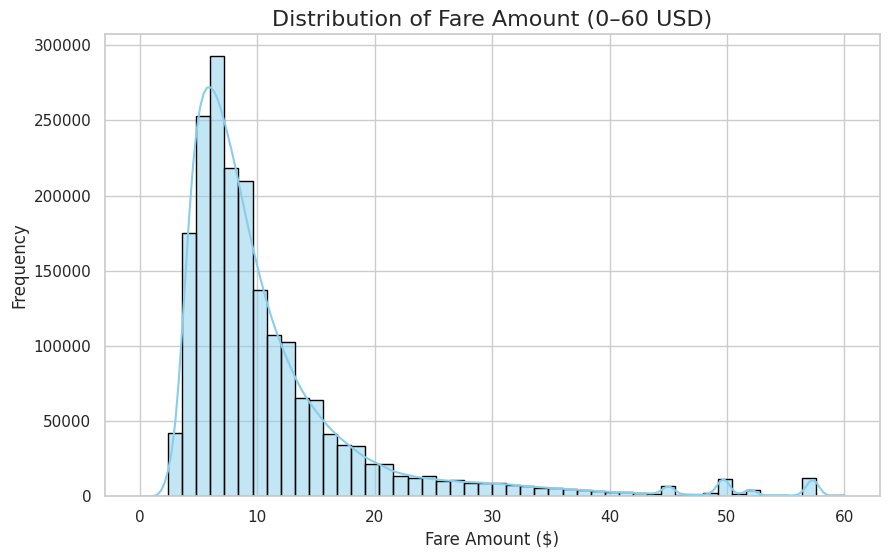

In [13]:
""" explore and plot the density plot of fare_amount """
# YOUR CODE HERE
filtered_df = df_dask1[(df_dask1['fare_amount'] >= 0) & (df_dask1['fare_amount'] <= 60)]

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['fare_amount'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Fare Amount (0–60 USD)', fontsize=16)
plt.xlabel('Fare Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

#### Observe the number of workers and cores running in your machine

Initialize a client and observe how many workers are working and the number of cores utilizing for the given data set.

In [14]:
""" Initialize a client """
# YOUR CODE HERE
client = Client()
print(client)

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:44135
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:38913/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45789'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39509'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37167'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37589'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36979'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44531'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41751'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44289'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40461'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43317'
INFO:distributed.nanny:        Start Nanny at: 

<Client: 'tcp://127.0.0.1:44135' processes=12 threads=96, memory=334.56 GiB>


### EDA based on Time

#### Exercise 4: Extract day of the week (dow), hour, month and year from `pickup_datetime`. (1 Point)

**Hint:** use `pd.to_datetime()` function as dask does not have this functionality in it.

Remember to use `.compute()` while passing the dask dataframe in defined function.

In [15]:
# YOUR CODE HERE
df_dask1['pickup_datetime'] = pd.to_datetime(df_dask1['pickup_datetime'], errors='coerce')

df_dask1['pickup_dayofweek'] = df_dask1['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
df_dask1['pickup_hour'] = df_dask1['pickup_datetime'].dt.hour
df_dask1['pickup_month'] = df_dask1['pickup_datetime'].dt.month
df_dask1['pickup_year'] = df_dask1['pickup_datetime'].dt.year

INFO:distributed.core:Event loop was unresponsive in Nanny for 5.82s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 5.88s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 5.90s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 5.92s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 5.96s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeout

In [16]:
print(df_dask1[['pickup_datetime', 'pickup_dayofweek', 'pickup_hour', 'pickup_month', 'pickup_year']].head())

            pickup_datetime  pickup_dayofweek  pickup_hour  pickup_month  \
0 2011-08-18 00:35:00+00:00                 3            0             8   
1 2012-04-21 04:30:42+00:00                 5            4             4   
2 2012-11-20 20:35:00+00:00                 1           20            11   
3 2012-04-08 07:30:50+00:00                 6            7             4   
4 2013-07-02 19:54:00+00:00                 1           19             7   

   pickup_year  
0         2011  
1         2012  
2         2012  
3         2012  
4         2013  


#### Exercise 5: a.) Plot the taxi trip by hour of the day  (0.5 Points)

* Partition the data into segments using `dask.from_pandas()`

* Plot the taxi trip for hour of the day. **Hint:** [sns.catplot](https://seaborn.pydata.org/generated/seaborn.catplot.html)

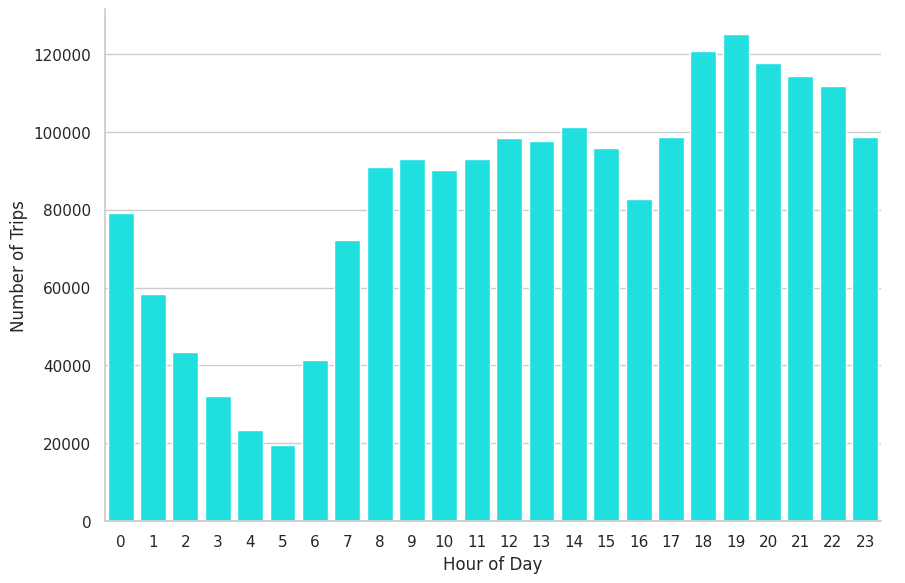

In [17]:
""" taxi trip repartition by hour of the day """
# YOUR CODE HERE
df_dask_partition= dd.from_pandas(df_dask1, npartitions=4)
df_hr = df_dask_partition[['pickup_hour']].compute()

# Plot
sns.set(style="whitegrid")
plot = sns.catplot(
    data = df_hr,
    x = 'pickup_hour',
    kind = 'count',
    height = 6,
    aspect = 1.5,
    color='cyan'
)
plot.set_axis_labels("Hour of Day", "Number of Trips")
plot.set_titles("Taxi Trips by Hour of Day")
plt.xticks(range(0, 24))
plt.show()

#### Exercise 5: b.) Plot the taxi trip repartition by day of the week (dow) (0.5 Points)

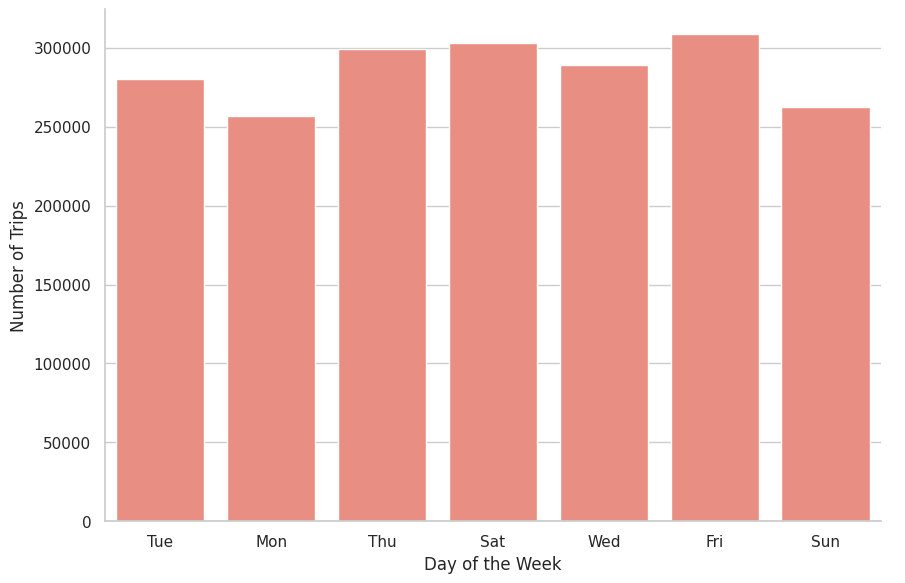

In [18]:
""" taxi trip repartition by day of the week """
# YOUR CODE HERE
# df_dask_partition= dd.from_pandas(df_dask1, npartitions=4)
df_wk = df_dask_partition[['pickup_dayofweek']].compute()

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_wk['pickup_dayofweek'] = df_wk['pickup_dayofweek'].map(lambda x: dow_labels[x])

# Plot
sns.set(style="whitegrid")
plot = sns.catplot(
    data=df_wk,
    x='pickup_dayofweek',
    kind='count',
    height=6,
    aspect=1.5,
    color='salmon'
)
plot.set_axis_labels("Day of the Week", "Number of Trips")
plot.set_titles("Taxi Trip Distribution by Day of the Week")
plt.show()

#### Exercise 6: a.) Draw a plot between the target variable and passenger count and analyze it.  (0.5 Points)

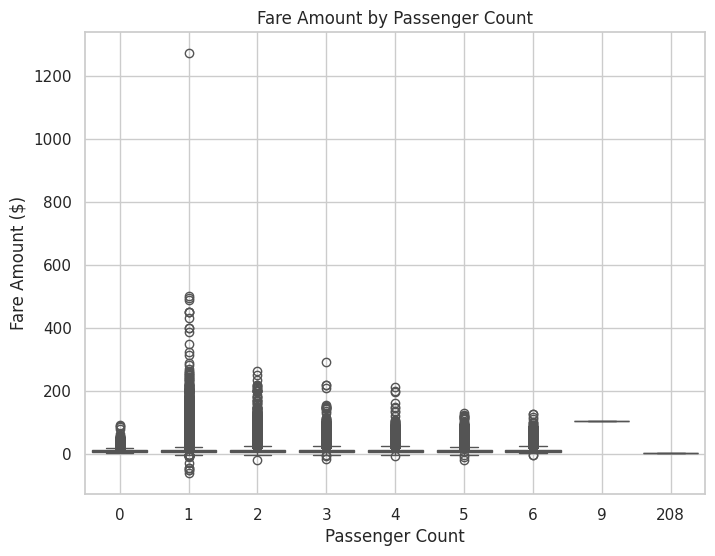

In [19]:
""" passenger count feature """
# YOUR CODE HERE
# df_pc = df_dask_partition[
#     (df_dask_partition['fare_amount'] > 0) &
#     (df_dask_partition['fare_amount'] < 100) &  #upper bound
#     (df_dask_partition['passenger_count'] > 0) &
#     (df_dask_partition['passenger_count'] <= 6)  #6 passengers
# ]

df_pc = df_dask_partition[['fare_amount','passenger_count']].compute()

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_pc, x='passenger_count', y='fare_amount', palette='coolwarm')
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

#### Exercise 6: b.) Draw a plot between the target variable and hour and analyze it. (0.5 Points)

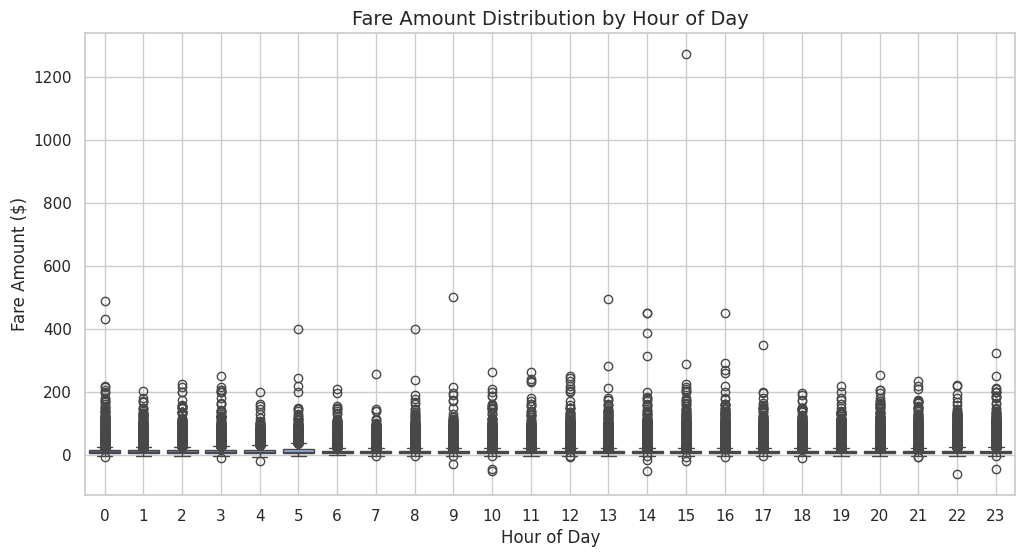

In [20]:
""" fare amount by hour """
# YOUR CODE HERE

df_hr2 = df_dask_partition[['pickup_hour','fare_amount']].compute()
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_hr2, x='pickup_hour', y='fare_amount', palette='coolwarm')

plt.title('Fare Amount Distribution by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(True)
plt.show()

### Feature Engineering

#### Exercise 7: Compute the Haversine distance between pickup and dropoff point. (1 Point)

* Convert the latitude and longitude co-rodinates to radians

* Calculate the Haversine distance

  **Hint:** [haversine_distances](https://towardsdatascience.com/heres-how-to-calculate-distance-between-2-geolocations-in-python-93ecab5bbba4)

* Add the "distance" feature to the dataset and plot its distribution

In [21]:
""" distance feature """
# YOUR CODE HERE
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371  # Radius of Earth in km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    res = r * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))
    return np.round(res, 2)

df_dask_partition['haversine_distance_km'] = df_dask_partition.apply(
    lambda row: haversine_distance(
        row['pickup_latitude'],
        row['pickup_longitude'],
        row['dropoff_latitude'],
        row['dropoff_longitude']
    ),
    axis=1
)
print(df_dask_partition[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'haversine_distance_km']].head())

   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0        40.711303        -74.016048         40.782004         -73.979268   
0        40.721319        -73.844311         40.712278         -73.841610   
0        40.761270        -73.982738         40.750562         -73.991242   
1        40.768008        -73.968095         40.783762         -73.956655   
1        40.731630        -74.000964         40.758233         -73.972892   

   haversine_distance_km  
0                   8.45  
0                   1.03  
0                   1.39  
1                   2.00  
1                   3.79  


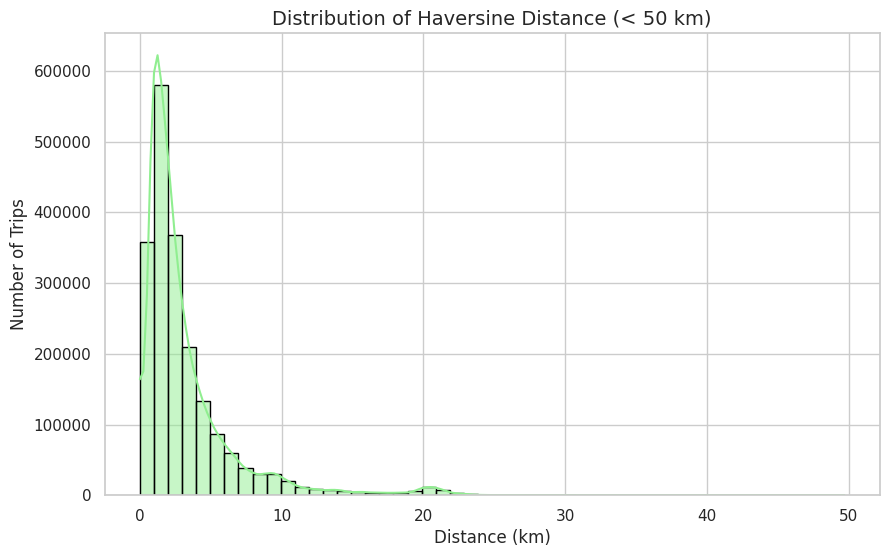

In [22]:
""" plot the distance feature (take distance < 50) """
# YOUR CODE HERE
df_distance = df_dask_partition[(df_dask_partition['haversine_distance_km'] < 50)].compute()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_distance,
    x='haversine_distance_km',
    bins=50,
    kde=True,
    color='lightgreen',
    edgecolor='black'
)
plt.title('Distribution of Haversine Distance (< 50 km)', fontsize=14)
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(True)
plt.show()

### Show the plot between distance and fare amount

**Hint:** [sns.scatterplot()](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

INFO:distributed.core:Event loop was unresponsive in Nanny for 3.40s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.40s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.40s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.41s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.41s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts an

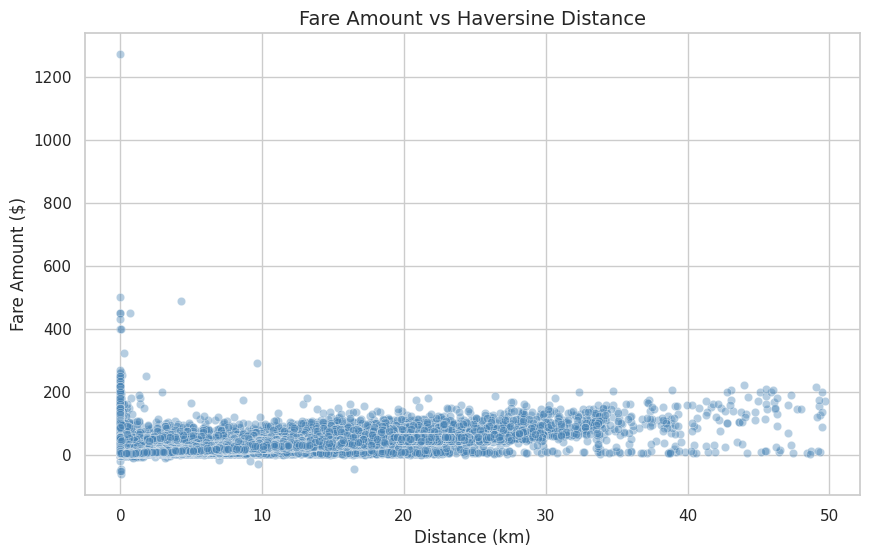

In [23]:
""" correlation between fare_amount and distance """
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_distance,
    x='haversine_distance_km',
    y='fare_amount',
    alpha=0.4,
    color='steelblue'
)

plt.title('Fare Amount vs Haversine Distance', fontsize=14)
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(True)
plt.show()

In [24]:
df_distance.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_dayofweek', 'pickup_hour', 'pickup_month', 'pickup_year',
       'haversine_distance_km'],
      dtype='object')

### Preparing dataset for model implementation

**Note:** Use the above modified dataset for modelling.

In [25]:
# YOUR CODE HERE
features = [
    'haversine_distance_km',
    'passenger_count',
    'pickup_hour',
    'pickup_dayofweek',
    'pickup_month',
    'pickup_year'
]

target = 'fare_amount'

X = df_distance[features]
y = df_distance[target]

print(X.shape)
print(y.shape)

(1995180, 6)
(1995180,)


### Removing outliers from training set Based on Coordinates

#### Exercise 8: Remove the outliers using the given latitude and longitude features from the dataset. We need to analyze the data of taxi within New York City. (1 Point)

**Hint:** Given the co-ordinates of New York city are Latitude: 40.7128° and Longitude: -74.0060°. You can include the pickup and drop off points such that there left and right value mean will be the given co-ordinate value.

Also, choose nearest extreme values.

Use `.between()` and pass left and right value attributes accordingly.

In [26]:
""" remove the outliers in pickup latitude longitude and drop off latitude and longitude """
# YOUR CODE HERE
lat_min = 40.5128
lat_max = 41.9128
lon_min = -74.2060
lon_max = -73.8060

df_distf = df_distance[
    df_distance['pickup_latitude'].between(lat_min, lat_max) &
    df_distance['pickup_longitude'].between(lon_min, lon_max) &
    df_distance['dropoff_latitude'].between(lat_min, lat_max) &
    df_distance['dropoff_longitude'].between(lon_min, lon_max)
]

# View result
print(f"Original dataset size: {df_distance.shape}")
print(f"Filtered NYC dataset size: {df_distf.shape}")
print(f"Diffrerence: {df_distance.shape[0] - df_distf.shape[0]}")

Original dataset size: (1995180, 12)
Filtered NYC dataset size: (1910359, 12)
Diffrerence: 84821


### Modelling

#### Exercise 9: Divide the data into train and test splits with X as feature variables and y as target variable  (1 Point)

* Divide data into train test split with 70-30 ratio, Hint: `train_test_split()`

* As dask functions operate lazily so, before calling `.fit()` function, call the dask dataframe with `.compute()`.
* Convert X_train and y_train into array using `.values` as [dask's](https://ml.dask.org/modules/api.html) `.fit()` function takes array as attribute

In [27]:
""" select the target and feature variables and split the data into train and test """
# YOUR CODE HERE
X = df_distf[features]
y = df_distf[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)


#### Exercise 10: Predict the test data and calculate the mean squared error and r2 score. (1 Point)

**Hint:** Remember to call `.compute()` function as dask functions operate lazily and convert the dask dataframe to `.values` (Array type) as suggested in above exercise

In [28]:
print(type(X_train), type(y_train), type(X_test), type(y_test))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'> <class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


In [29]:
X_train2 = dd.from_array(X_train.to_numpy()).compute()
y_train2 = dd.from_array(y_train.to_numpy()).compute()

In [30]:
X_test2 = dd.from_array(X_test.to_numpy()).compute()
y_test2 = dd.from_array(y_test.to_numpy()).compute()

In [31]:
X_train3 = X_train2.values
y_train3 = y_train2.values

X_test3 = X_test2.values
y_test3 = y_test2.values


print("X_train :", X_train3.shape)
print("y_train :", y_train3.shape)
print("X_test :" , X_test3.shape)
print("y_test :" , y_test3.shape)

X_train : (1337251, 6)
y_train : (1337251,)
X_test : (573108, 6)
y_test : (573108,)


In [32]:
""" predict the values """

# YOUR CODE HERE
model = LinearRegression()
model.fit(X_train3, y_train3)



# Predict
y_pred = model.predict(X_test3)

In [33]:
print(len(y_pred))

573108


In [34]:
print(type(y_pred))

<class 'numpy.ndarray'>


In [35]:
y_pred3 = dd.from_array(y_pred).compute()

In [41]:
print(type(y_test3),y_test3.shape,type(y_pred3),y_pred3.shape)
# Convert y_pred3 to a NumPy array if it's a pandas Series
if isinstance(y_pred3, pd.Series):
    y_pred3_np = y_pred3.to_numpy()
else:
    y_pred3_np = y_pred3 # Assume it's already a NumPy array
print(type(y_test3),y_test3.shape,type(y_pred3),y_pred3.shape,type(y_pred3_np),y_pred3_np.shape)

<class 'numpy.ndarray'> (573108,) <class 'pandas.core.series.Series'> (573108,)
<class 'numpy.ndarray'> (573108,) <class 'pandas.core.series.Series'> (573108,) <class 'numpy.ndarray'> (573108,)


In [42]:
mse = mean_squared_error(y_test3, y_pred3,compute=False)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 19.62


In [48]:
y_test3_np = np.array(y_test3, dtype=np.float64)

In [47]:
# y_pred4 = y_pred3.to_numpy()
r2 = r2_score(y_true=y_test3_np,y_pred=y_pred3_np,compute=False)

print(f"R² Score: {r2:.2f}")


ValueError: An error occurred while calling the wrap_func_shape_as_first_arg method registered to the numpy backend.
Original Message: You must specify a chunks= keyword argument.
This specifies the chunksize of your array blocks.

See the following documentation page for details:
  https://docs.dask.org/en/latest/array-creation.html#chunks

In [ ]:
# """ compute mean squared error and r2_score """
# # YOUR CODE HERE
# # y_test2 = da.asarray(y_test1, chunks='auto')
# #y_pred = da.asarray(y_pred, chunks='auto')

# mse = mean_squared_error(y_test1, y_pred)
# r2 = r2_score(y_test1, y_pred)

# print(f"Mean Squared Error: {mse:.2f}")
# print(f"R² Score: {r2:.2f}")

### Report Analysis
* Discuss the pros and cons of using dask
* Derive the insights and discuss
* Comment on the performance metrics (MSE, $R^2$ score)
